# Recovery against the horizon

Sample paths of the ARI against $n$, at fixed $N$ — the published Figure 4, with the outer
level of randomness the design was missing.

That figure drew the kernels once and replicated the data 50 times, so everything it showed
was a property of one draw of a $K = 4$ mixture at $\alpha = 0.3$. The rise from 0.67 to 1
it reported may or may not be typical; nothing in the experiment separated the mixture from
the draw. Here several mixtures are drawn, each held fixed while its datasets are
replicated, so the figure carries both: the spread between replicates of one mixture, and
the spread between mixtures.

Everything else is unchanged. A replicate is a genuine sample path — the same $N$ sequences
read at growing lengths, through the nested prefixes of `om_matrices` — so the thin lines
show the variability of a single experiment, not an interval around the mean. The three
estimators share these axes exactly, so the figures stack and compare.


In [1]:
%load_ext autoreload
%autoreload 2

import time
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from clustering import adjusted_rand_index
from experiments import (ResultsWriter, draw_markov_mixture, labels_at_k,
                         save_mixture, stream, univariate_om)
from figures import PAPER_STYLE, plot_paths, save

## Setup

Everything reported below is produced by the sweep in this notebook. Every run starts fresh,
overwrites its dedicated tables and never reads rows from an earlier run: the notebook is here
to reproduce the section, not to store it. The default computation takes about twenty minutes
at $N = 200$, and roughly sixteen times that at the published $N = 800$.

In [ ]:
# --- the knobs -------------------------------------------------------------
ALPHA_FIX = 1
K_FIX = 4
PATH_N = 800               # use 800 for the published setting
N_MIX = 1
N_DATA = 30
HORIZONS = np.arange(50, 550, 50, dtype=int)
D_STATES = 5
COST = "constant"
SEED = 20260901
PAM_RESTARTS = 1
PATH_ALGOS = ("single", "average", "pam")

RESULTS = Path("results")
FIGURES = Path("Figures/Recovery")
FIGURES.mkdir(parents=True, exist_ok=True)
OUT_PATH = RESULTS / "recovery_path_notebook_cluster.csv"

PATH_FIELDS = ["alpha", "K", "d", "mixture_id", "dataset_id", "n", "N",
               "cost_scheme", "algorithm", "ari", "mixture_key"]

om = univariate_om(COST, D_STATES, rng=stream(SEED, "cost", COST))
assumption = om.assumption_1()
metric_ok = all(v for k, v in assumption.items() if k.startswith("("))
print(f"cost scheme {om.name}: Assumption 1 holds = {metric_ok}, M = {om.M:.3f}")


def score_recovery_paths(mixture, matrices, truth, dataset_id, rng):
    """Only what this notebook plots: one partition per algorithm at known K."""
    rows = []
    for g, n in enumerate(HORIZONS):
        D = matrices[g]
        for algorithm in PATH_ALGOS:
            labels = labels_at_k(D, K_FIX, algorithm, rng=rng,
                                 pam_restarts=PAM_RESTARTS)
            rows.append({"alpha": ALPHA_FIX, "K": K_FIX, "d": mixture.d,
                         "mixture_id": mixture.mixture_id,
                         "dataset_id": dataset_id, "n": int(n), "N": PATH_N,
                         "cost_scheme": om.name, "algorithm": algorithm,
                         "ari": adjusted_rand_index(labels, truth),
                         "mixture_key": mixture.key})
    return rows


def compute_paths():
    """Draw the mixtures and score the ARI of every algorithm along the horizons."""
    OUT_PATH.unlink(missing_ok=True)
    path_writer = ResultsWriter(OUT_PATH, PATH_FIELDS)
    start = time.perf_counter()
    try:
        for m in range(N_MIX):
            mixture = draw_markov_mixture(K_FIX, D_STATES, ALPHA_FIX, m, SEED)
            save_mixture(mixture, RESULTS / "mixtures" / "recovery-path")
            for r in range(N_DATA):
                rng = stream(SEED, "path-data", ALPHA_FIX, K_FIX, m, r)
                X, truth = mixture.sample_dataset(PATH_N, int(HORIZONS[-1]), rng)
                matrices = om.matrices(X, HORIZONS)
                rows = score_recovery_paths(mixture, matrices, truth, r, rng)
                path_writer.write([{k: row.get(k, "") for k in PATH_FIELDS}
                                   for row in rows])
            elapsed = time.perf_counter() - start
            left = (N_MIX - m - 1) * elapsed / (m + 1)
            print(f"mixture {m + 1}/{N_MIX}, ~{left/60:.1f} min left", flush=True)
    finally:
        path_writer.close()


compute_paths()

path = pd.read_csv(OUT_PATH)
print(f"alpha = {ALPHA_FIX}, K = {K_FIX}, N = {PATH_N}; "
      f"{N_MIX} mixtures x {N_DATA} datasets over horizons {list(HORIZONS)}")

cost scheme constant: Assumption 1 holds = True, M = 2.000


100%|██████████| 10/10 [00:00<00:00, 12.28it/s]


## The figure

Same layout as `plot_gamma_convergence` in `om_convergence.ipynb`: one thin line per
replicate, the mean over them on top. The intermediate lines are the per-mixture means —
the level the published figure could not show, since it had a single mixture. Where they
fan out, the horizon needed for recovery depends on which kernels were drawn; where they
collapse onto the mean, it does not.

In [ ]:
COL = {"single":  "#1b6ca8",       # the blue of om_convergence.ipynb
       "average": "#6a51a3",       # a third hue, so no two estimators share a colour
       "pam":     "#c0392b"}
NAMES = {"single": "single linkage", "average": "average linkage", "pam": "PAM"}


def curves(df, algorithm, value="ari"):
    """(replicate, horizon) array, plus the per-mixture means."""
    sub = df[df.algorithm == algorithm]
    wide = sub.pivot_table(index=["mixture_id", "dataset_id"], columns="n", values=value)
    wide = wide.reindex(columns=HORIZONS)
    per_mixture = sub.pivot_table(index="mixture_id", columns="n", values=value)
    return wide.to_numpy(), per_mixture.reindex(columns=HORIZONS).to_numpy()


def plot_ari_curve(algorithm, filename=None):
    reps, per_mixture = curves(path, algorithm)
    colour = COL[algorithm]
    with plt.rc_context(PAPER_STYLE):
        fig, ax = plt.subplots(figsize=(5.2, 4.0))
        plot_paths(ax, HORIZONS, reps, per_mixture, colour,
                   f"ARI, {NAMES[algorithm]}", rf"{NAMES[algorithm]} --- $N = {PATH_N}$, "
                   rf"$K = {K_FIX}$, $\alpha = {ALPHA_FIX}$")
        fig.tight_layout()
        if filename is not None:
            save(fig, FIGURES, filename)
        plt.show()
    return fig


### Average linkage

figure written to Figures\Recovery\ari_path_average_linkage.pdf


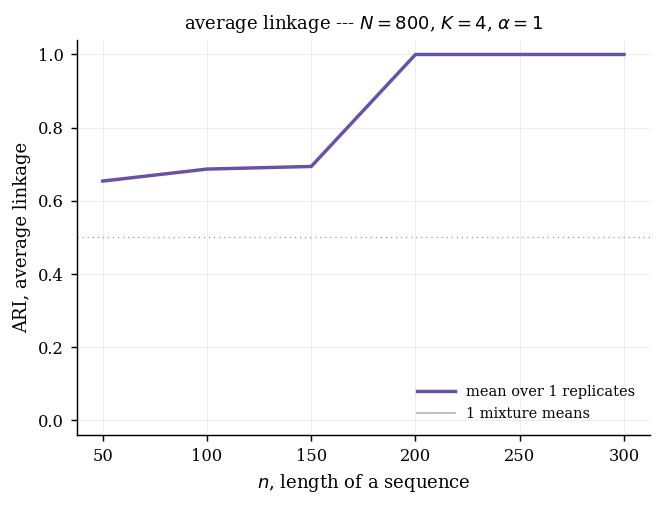

In [ ]:
_ = plot_ari_curve("average", filename="ari_path_average_linkage")

### PAM

figure written to Figures\Recovery\ari_path_pam.pdf


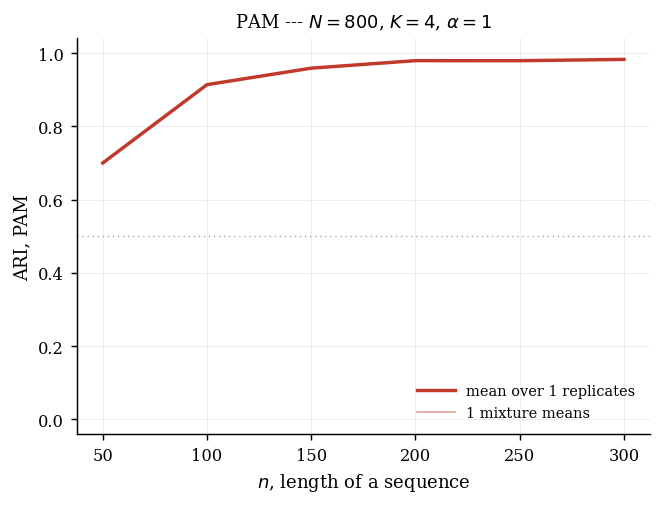

In [ ]:
_ = plot_ari_curve("pam", filename="ari_path_pam")

## Appendix: single linkage

The estimator Theorem 3.5 is about, on the same axes, where the published Figure 9 had it.

figure written to Figures\Recovery\ari_path_single_linkage.pdf


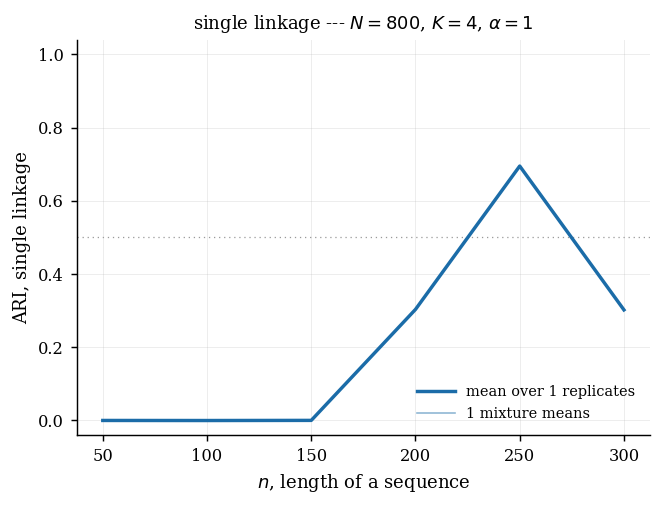

In [ ]:
_ = plot_ari_curve("single", filename="ari_path_single_linkage")